In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints
from primordialpy.inducedGW import InducedGW

import matplotlib.pyplot as plt

In [2]:
V = '3*M**2/4*(1 - exp(-sqrt(2/3)*phi))**2*(1 + B1*C1/((phi - D1)**2 + C1**2))'
parameters = {'M' : 1.3e-5, 'B1' : 6.23278e-5, 'C1': 0.025, 'D1': 4}
potential = PotentialFunction.from_string(V, param_values=parameters) 

#Creando instancia de la clase Background. Resuelve automáticamente el sistema dada la condición inicial del inflatón
background = Background(potential, phi0 = 5.4) 
background.solver()

In [3]:
#Extrayendo datos de la clase background
vars = ['N', 'phi', 'dphidN', 'H', 'a', 'aH', 'eps_H', 'eta_H']
N, phi, dphidN, H, a, aH, eps_H, eta_H = [background.data(save=True)[i] for i in vars]
N[-1]

67.40674067406741

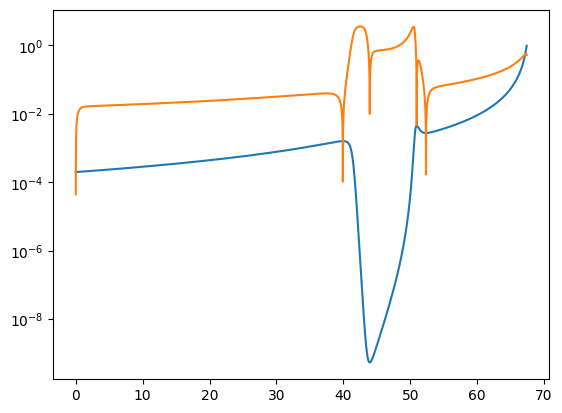

In [4]:
plt.semilogy(N, eps_H)
plt.semilogy(N, abs(eta_H))

In [5]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 60)
sol = pert.Power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.051094728271491e-09
Tensor to scalar ratio at pivot scale is 0.004037319891749321


In [6]:
PS = pert.Power_spectrum(save = True)

Computing P(k): 100%|██████████| 1000/1000 [01:26<00:00, 11.53it/s]


k_peak = 1.21\times 10^{+14} Mpc^-1
N_peak = 42.85532429624972
P_s(k_peak) = 0.013887609547927986


<Figure size 800x500 with 0 Axes>

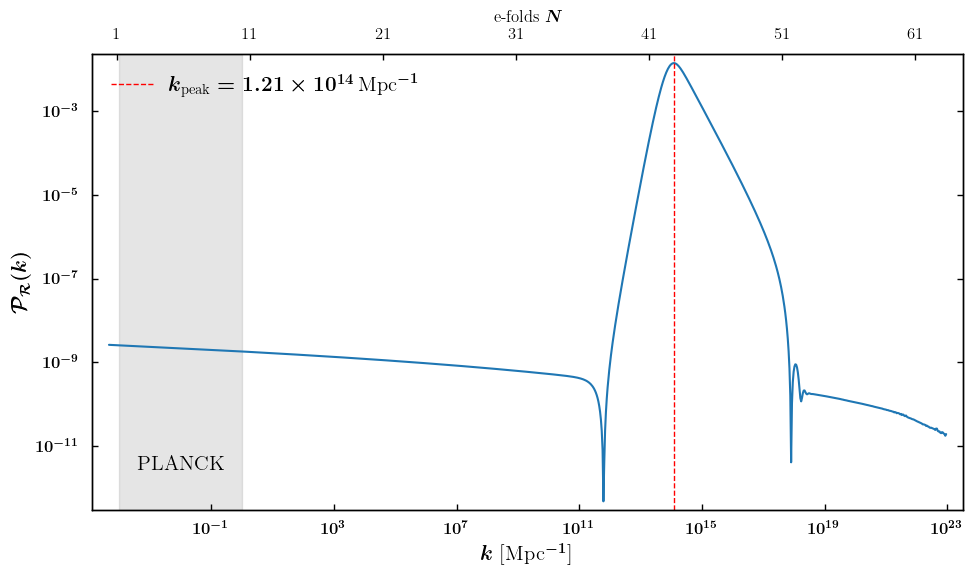

In [7]:
pert.Plot_spectrum(dpi = 100, spectrum = 'scalar')

In [8]:
print(pert.Spectral_tilts)

{'n_s': 0.9624096980525625, 'n_t': -0.0006295168591144997}


In [ ]:
pbh = PBHAbundance(pert, delta_c=0.35, gamma=0.2, gstar=107.5)
mPBH, fPBH = pbh.fPBH(save=True)

fPBH_peak = 5.557929016862577e-09
MPBH_peak = 2.4860863044095265e-16 M⊙


  [OK] Loaded data: Evap
  [OK] Loaded data: HSC
  [ERROR] Failure to read CMB.txt: the number of columns changed from 2 to 1 at row 9; use `usecols` to select a subset and avoid this error
  [OK] Loaded data: LIGO
  [OK] Loaded data: Accretion
  [OK] Loaded data: Dynamical
  [OK] Loaded data: EROS
  [OK] Loaded data: Kepler
  [OK] Loaded data: Microlensing
fPBH_peak = 5.557929016862577e-09
MPBH_peak = 2.4860863044095265e-16 M⊙
fPBH_peak = 5.557929016862577e-09
MPBH_peak = 2.4860863044095265e-16 M⊙
Figure saved to: Figures/Paper_Figure_Final.pdf


<Figure size 2400x1500 with 0 Axes>

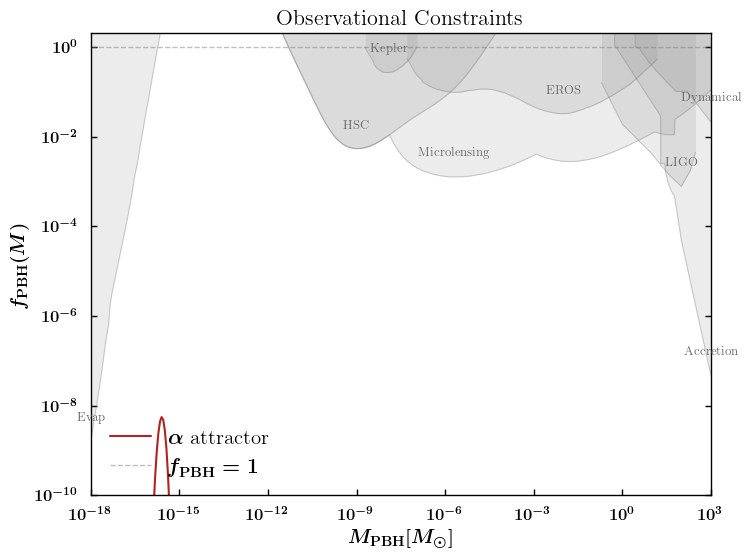

In [15]:
constraints = PBHConstraints()
constraints.add_bound('Evap', 'Evaporation.txt')
constraints.add_bound('HSC',  'HSC.txt')
constraints.add_bound('CMB', 'CMB.txt')
constraints.add_bound('LIGO', 'LIGO.txt')
constraints.add_bound('Accretion', 'Accretion.txt')
constraints.add_bound('Dynamical', 'Dynamical.txt')
constraints.add_bound('EROS', 'EROS.txt')
constraints.add_bound('Kepler', 'Kepler.txt')
constraints.add_bound('Microlensing', 'Microlensing.txt')


constraints.plot_constraints(pbh, label= r"$\alpha$ attractor", filename='Paper_Figure_Final.pdf')